Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
Modelación y Simulación - sección 10

Cristian Túnchez (231359)  
Daniel Chet (231177)

# Laboratorio 3 — Task 2: modelo SIR, calibración y validación

Este notebook resuelve el **Task 2** del Laboratorio 3. Implementa el modelo SIR con RK4, lo compara contra los infectados observados de las primeras cuatro semanas del brote, calibra el parámetro de transmisión, corre un análisis de sensibilidad y aplica los tres criterios de validación vistos en clase.

**Contenido**

- **2.1 (a)** Implementación del SIR con RK4, reporte de $\hat I(t)$ semanal y SCE
- **2.1 (b)** Hipótesis sobre el parámetro mal especificado
- **2.1 (c)** Análisis de sensibilidad en $\beta$
- **2.2 (a)** Los tres criterios de validación
- **2.2 (b)** Limitación estructural y extensión propuesta

El modelo y el integrador usan **solo NumPy**. `pandas` sirve únicamente para mostrar tablas y `matplotlib` para graficar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## Parámetros

Se heredan del Task 1.1. El tiempo se mide en **días**.

| Símbolo | Significado | Valor | Unidad |
|---|---|---|---|
| $N$ | población total | 500 000 | habitantes |
| $S_0$ | susceptibles iniciales | 499 000 | habitantes |
| $I_0$ | infectados iniciales | 800 | habitantes |
| $R(0)$ | recuperados iniciales | 200 | habitantes |
| $\gamma$ | tasa de recuperación, $1/7$ | 0.142857 | $\text{día}^{-1}$ |
| $\beta$ | tasa de transmisión, $\mathcal{R}_0\,\gamma$ | 0.4 | $\text{día}^{-1}$ |
| $\mathcal{R}_0$ | número reproductivo básico | 2.8 | — |

Los datos que entrega la agencia son los infectados **activos** al final de cada semana.

In [2]:
# Población y condiciones iniciales
N = 500_000.0
I0 = 800.0
R_ini = 200.0
S0 = N - I0 - R_ini

# Parámetros del Task 1.1
gamma = 1 / 7          # día^-1
R0_base = 2.8
beta_base = R0_base * gamma   # día^-1

# Datos observados: infectados activos al final de cada semana
semanas = np.array([1, 2, 3, 4])
I_obs = np.array([1850.0, 4200.0, 8900.0, 16400.0])

y0 = np.array([S0, I0, R_ini])
print(f"S0 = {S0:,.0f}   I0 = {I0:,.0f}   R(0) = {R_ini:,.0f}")
print(f"gamma = {gamma:.6f} /día   beta = {beta_base:.6f} /día   R0 = {R0_base}")

S0 = 499,000   I0 = 800   R(0) = 200
gamma = 0.142857 /día   beta = 0.400000 /día   R0 = 2.8


## El modelo SIR

$$\frac{dS}{dt} = -\beta\,\frac{S I}{N}, \qquad
\frac{dI}{dt} = \beta\,\frac{S I}{N} - \gamma I, \qquad
\frac{dR}{dt} = \gamma I$$

El término $\beta S I / N$ es la fuerza de infección y mueve personas de $S$ a $I$. El término
$\gamma I$ mueve personas de $I$ a $R$. La suma de las tres derivadas es cero, por lo que $N$ se
conserva.

In [3]:
def derivadas(y, beta, gamma, N):
    # Campo vectorial del SIR: recibe [S, I, R] y devuelve [dS, dI, dR]
    S, I, R = y
    infeccion = beta * S * I / N
    recuperacion = gamma * I
    return np.array([-infeccion, infeccion - recuperacion, recuperacion])

## Integrador: Runge–Kutta de orden 4

RK4 avanza un paso $\Delta t$ combinando cuatro evaluaciones del campo vectorial:

$$y_{k+1} = y_k + \frac{\Delta t}{6}\left(k_1 + 2k_2 + 2k_3 + k_4\right)$$

con $k_1 = f(y_k)$, $k_2 = f\!\left(y_k + \tfrac{\Delta t}{2}k_1\right)$,
$k_3 = f\!\left(y_k + \tfrac{\Delta t}{2}k_2\right)$ y $k_4 = f\!\left(y_k + \Delta t\,k_3\right)$.

Se usa $\Delta t = 0.1$ días, que divide exactamente a 7 días y permite leer los valores semanales
por índice, sin interpolar.

In [4]:
DT = 0.1   # días

def rk4(f, y0, dt, T, *args):
    # Integra y' = f(y, *args) de 0 a T. Devuelve (t, Y) con Y de forma (n+1, 3)
    n = int(round(T / dt))
    t = np.linspace(0.0, n * dt, n + 1)
    Y = np.zeros((n + 1, len(y0)))
    Y[0] = y0
    y = np.array(y0, dtype=float)
    for k in range(n):
        k1 = f(y, *args)
        k2 = f(y + dt / 2 * k1, *args)
        k3 = f(y + dt / 2 * k2, *args)
        k4 = f(y + dt * k3, *args)
        y = y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        Y[k + 1] = y
    return t, Y


def simular(beta, T, dt=DT):
    # Atajo: corre el SIR con un beta dado
    return rk4(derivadas, y0, dt, T, beta, gamma, N)


# Índices de las semanas 1 a 4 dentro del arreglo de tiempo
idx_semanas = np.rint(semanas * 7 / DT).astype(int)
print("Índices de t que corresponden a las semanas 1-4:", idx_semanas)

Índices de t que corresponden a las semanas 1-4: [ 70 140 210 280]


## 2.1 (a) Simulación base y suma de cuadrados del error

Se corre el modelo 28 días con los parámetros del Task 1.1 y se compara $\hat I(t)$ contra los datos
observados de cada semana. La suma de cuadrados del error es

$$\text{SCE} = \sum_{k=1}^{4}\left(I^{obs}_k - \hat I_k\right)^2$$

In [5]:
def infectados_semanales(beta):
    # Devuelve el I(t) del modelo en las semanas 1 a 4
    _, Y = simular(beta, T=28)
    return Y[idx_semanas, 1]


def sce(beta):
    # Suma de cuadrados del error contra los datos observados
    return float(np.sum((I_obs - infectados_semanales(beta)) ** 2))


I_mod_base = infectados_semanales(beta_base)
sce_base = sce(beta_base)

tabla_base = pd.DataFrame({
    "Semana": semanas,
    "I_obs": I_obs,
    "I_modelo": I_mod_base,
    "Residuo (obs - mod)": I_obs - I_mod_base,
})
print(f"beta = {beta_base:.4f} /día   R0 = {R0_base}")
print(f"SCE  = {sce_base:.4e}\n")
tabla_base

beta = 0.4000 /día   R0 = 2.8
SCE  = 2.2174e+10



,Semana,I_obs,I_modelo,Residuo (obs - mod)
0,1,"1,850.00","4,753.15","-2,903.15"
1,2,"4,200.00","25,757.21","-21,557.21"
2,3,"8,900.00","92,842.82","-83,942.82"
3,4,"16,400.00","137,455.37","-121,055.37"


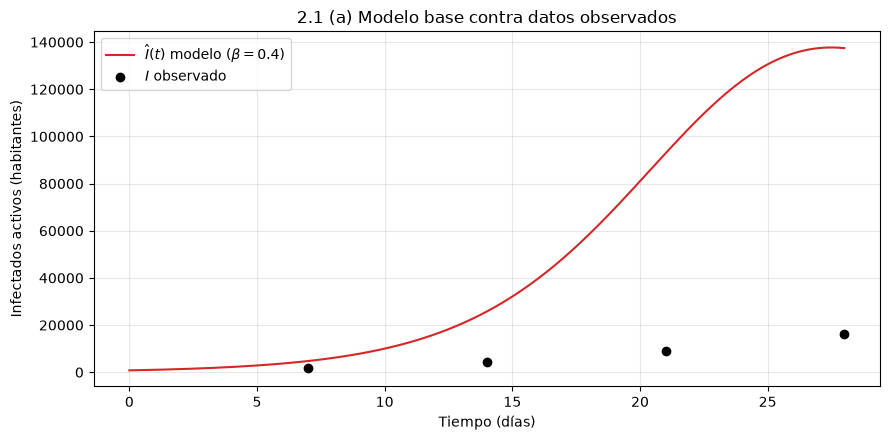

In [6]:
t, Y = simular(beta_base, T=28)

plt.plot(t, Y[:, 1], label=r"$\hat I(t)$ modelo ($\beta = 0.4$)", color="tab:red")
plt.scatter(semanas * 7, I_obs, color="black", zorder=5, label="$I$ observado")
plt.xlabel("Tiempo (días)")
plt.ylabel("Infectados activos (habitantes)")
plt.title("2.1 (a) Modelo base contra datos observados")
plt.legend()
plt.tight_layout()
plt.show()

## 2.1 (b) Hipótesis sobre el parámetro mal especificado

**El parámetro mal especificado es $\beta$, y debe corregirse hacia abajo.**

*Justificación*: al inicio del brote $S \approx N$, así que la ecuación de infectados se reduce a $dI/dt \approx (\beta - \gamma)\,I$ y la epidemia crece exponencialmente con tasa

$$r = \beta\,\frac{S_0}{N} - \gamma$$

Esa tasa es la única cantidad que fija la pendiente inicial de la curva, y en ella solo aparecen dos parámetros. $\gamma$ no es libre, queda determinado por el dato clínico del período infeccioso de 7
días. Por lo tanto, toda la discrepancia en la pendiente inicial recae sobre $\beta$.

Los datos observados crecen a $r \approx 0.11$ $\text{día}^{-1}$, mientras que el modelo crece a $r = 0.256$ $\text{día}^{-1}$. Como el modelo crece más rápido que los datos, $\beta$ está **sobreestimado** y debe reducirse hasta que ambas tasas coincidan, lo que equivale a un $\mathcal{R}_0$ menor.

> **Nota**: El inciso mencionaba que el modelo *subestima* los infectados observados, pero con los parámetros del Task 1.1 y los datos de las semanas, ocurre lo contrario. Los cuatro residuos $I^{obs}_k - \hat I_k$ de la tabla anterior son negativos. La corrección se plantea en la dirección que indican los datos.

### Calibración de $\beta$

Se busca el $\beta^{*}$ que minimiza el SCE mediante un barrido sobre una malla de valores.

In [7]:
malla_beta = np.linspace(0.15, 0.45, 3001)
sce_malla = np.array([sce(b) for b in malla_beta])

beta_est = float(malla_beta[np.argmin(sce_malla)])
sce_est = float(sce_malla.min())
I_mod_est = infectados_semanales(beta_est)

print(f"beta* = {beta_est:.4f} /día")
print(f"R0*   = {beta_est / gamma:.3f}")
print(f"SCE   = {sce_est:.4e}   (base: {sce_base:.4e})")
print(f"Reducción del SCE: {100 * (1 - sce_est / sce_base):.4f} %\n")

tabla_cal = pd.DataFrame({
    "Semana": semanas,
    "I_obs": I_obs,
    "I_modelo (beta*)": I_mod_est,
    "Residuo": I_obs - I_mod_est,
    "Residuo relativo (%)": 100 * (I_obs - I_mod_est) / I_obs,
})
tabla_cal

beta* = 0.2574 /día
R0*   = 1.802
SCE   = 6.0623e+05   (base: 2.2174e+10)
Reducción del SCE: 99.9973 %



,Semana,I_obs,I_modelo (beta*),Residuo,Residuo relativo (%)
0,1,"1,850.00","1,771.13",78.87,4.26
1,2,"4,200.00","3,874.32",325.68,7.75
2,3,"8,900.00","8,258.54",641.46,7.21
3,4,"16,400.00","16,687.17",-287.17,-1.75


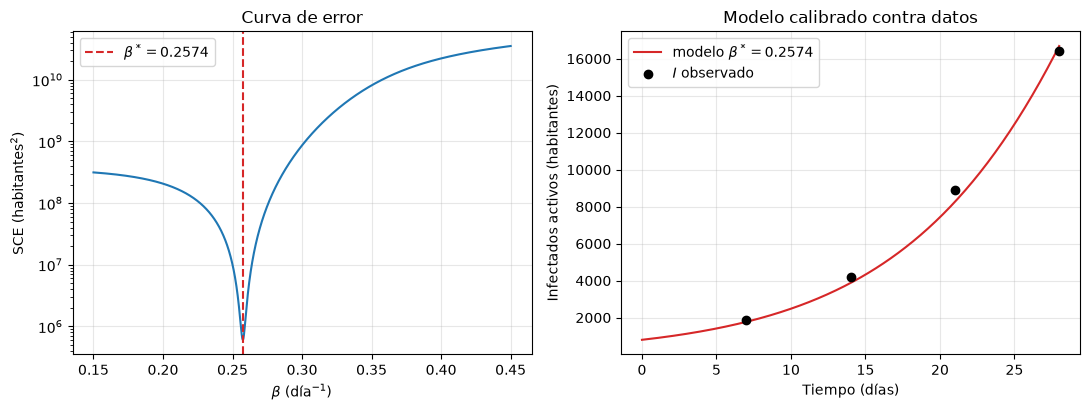

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.plot(malla_beta, sce_malla)
ax1.axvline(beta_est, color="tab:red", ls="--", label=rf"$\beta^* = {beta_est:.4f}$")
ax1.set_yscale("log")
ax1.set_xlabel(r"$\beta$ (día$^{-1}$)")
ax1.set_ylabel("SCE (habitantes$^2$)")
ax1.set_title("Curva de error")
ax1.legend()

t_cal, Y_cal = simular(beta_est, T=28)
ax2.plot(t_cal, Y_cal[:, 1], color="tab:red", label=rf"modelo $\beta^* = {beta_est:.4f}$")
ax2.scatter(semanas * 7, I_obs, color="black", zorder=5, label="$I$ observado")
ax2.set_xlabel("Tiempo (días)")
ax2.set_ylabel("Infectados activos (habitantes)")
ax2.set_title("Modelo calibrado contra datos")
ax2.legend()

fig.tight_layout()
plt.show()

## 2.1 (c) Análisis de sensibilidad en $\beta$

Se corre el modelo con $\beta \in \{0.8\beta^{*},\ \beta^{*},\ 1.2\beta^{*}\}$ manteniendo $\gamma$
fijo. Para cada valor se reporta el pico de $I(t)$, el tiempo al pico y el tamaño final de la
epidemia. El horizonte se extiende a 365 días porque el pico ocurre después de la cuarta semana.

In [9]:
T_LARGO = 365   # días

escenarios = [("0.8 beta*", 0.8 * beta_est), ("beta*", beta_est), ("1.2 beta*", 1.2 * beta_est)]
filas, trayectorias = [], {}

for etiqueta, b in escenarios:
    t_e, Y_e = simular(b, T=T_LARGO)
    trayectorias[etiqueta] = (t_e, Y_e)
    j = int(np.argmax(Y_e[:, 1]))
    filas.append({
        "Escenario": etiqueta,
        "beta (1/día)": f"{b:.4f}",
        "R0": f"{b / gamma:.3f}",
        "Pico de I (hab)": Y_e[j, 1],
        "Pico (% de N)": 100 * Y_e[j, 1] / N,
        "Tiempo al pico (días)": t_e[j],
        "Tamaño final (% de N)": 100 * Y_e[-1, 2] / N,
    })

tabla_sens = pd.DataFrame(filas)
pico_ref = tabla_sens.loc[tabla_sens["Escenario"] == "beta*", "Pico de I (hab)"].iloc[0]
tabla_sens["Variación del pico (%)"] = 100 * (tabla_sens["Pico de I (hab)"] - pico_ref) / pico_ref
tabla_sens

,Escenario,beta (1/día),R0,Pico de I (hab),Pico (% de N),Tiempo al pico (días),Tamaño final (% de N),Variación del pico (%)
0,0.8 beta*,0.2059,1.441,"26,786.69",5.36,79.40,54.44,-54.96
1,beta*,0.2574,1.802,"59,466.74",11.89,52.00,73.38,0.00
2,1.2 beta*,0.3089,2.162,"90,693.73",18.14,39.10,83.62,52.51


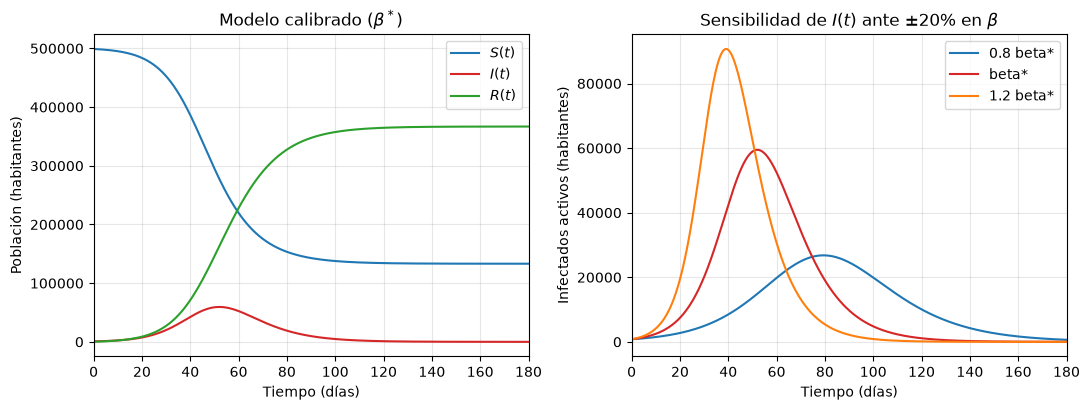

In [10]:
colores = {"0.8 beta*": "tab:blue", "beta*": "tab:red", "1.2 beta*": "tab:orange"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel izquierdo: las tres trayectorias del modelo calibrado
t_e, Y_e = trayectorias["beta*"]
ax1.plot(t_e, Y_e[:, 0], color="tab:blue", label="$S(t)$")
ax1.plot(t_e, Y_e[:, 1], color="tab:red", label="$I(t)$")
ax1.plot(t_e, Y_e[:, 2], color="tab:green", label="$R(t)$")
ax1.set_xlabel("Tiempo (días)")
ax1.set_ylabel("Población (habitantes)")
ax1.set_title(r"Modelo calibrado ($\beta^*$)")
ax1.set_xlim(0, 180)
ax1.legend()

# Panel derecho: I(t) para los tres valores de beta
for etiqueta, (t_s, Y_s) in trayectorias.items():
    ax2.plot(t_s, Y_s[:, 1], color=colores[etiqueta], label=etiqueta)
ax2.set_xlabel("Tiempo (días)")
ax2.set_ylabel("Infectados activos (habitantes)")
ax2.set_title(r"Sensibilidad de $I(t)$ ante $\pm 20\%$ en $\beta$")
ax2.set_xlim(0, 180)
ax2.legend()

fig.tight_layout()
plt.show()

### Interpretación

Una variación de $\pm 20\%$ en $\beta$ mueve el pico de infectados en **−54.9 %** y **+52.5 %**. El criterio visto en clase indica que si el pico varía más del 50% ante una variación del 20% en $\beta$, el modelo es **sensible** y sus conclusiones son inciertas. Este modelo cruza ese umbral en ambas direcciones.

El efecto también aparece en las otras dos métricas. El tiempo al pico se recorre de 79 a 39 días y el tamaño final de la epidemia pasa de 54% a 84% de la población. La recomendación práctica es reportar rangos de predicción y no valores puntuales.